# Notebook 05：单因子分层回测

本 Notebook 检验 Notebook 04 中观察到的因子排序能力，能否转化为具有经济意义的组合收益。每个信号形成日按因子从低到高把股票等频分成五组，Q1 最低、Q5 最高，使用下一持有期简单收益计算组内等权收益。

## 回测口径

- 样本：仅使用 Notebook 02 定义的 `is_in_label_sample=True` 主研究样本。
- 信号：Notebook 03 输出的逐月去极值、方向统一、横截面标准化因子；数值越大表示预期收益越高。
- 调仓：月频；当月月末形成信号，持有至下一正式月末调仓日。
- 分组：按因子排序后等频分为 Q1–Q5；因子值相同时以股票代码稳定打破排序并列。
- 权重：组内等权。
- 收益：使用未缩尾的 `future_return_1m`，不扣交易成本。
- 多空：`Long-Short = Q5 - Q1`。A股个股做空受限，因此这里主要作为因子收益的研究组合。
- 年化收益：月收益复利年化；年化波动率乘 `sqrt(12)`；Sharpe 假设无风险利率为零。

## 1. 环境与参数

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.portfolio import (
    annualized_return,
    build_factor_return_panel,
    calculate_cumulative_returns,
    calculate_quintile_returns,
    calculate_return_metrics,
)

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FACTOR_PANEL_PATH = PROCESSED_DIR / 'factor_panel_zscore.parquet'
N_QUINTILES = 5
MIN_OBSERVATIONS = 30
PERIODS_PER_YEAR = 12

FACTOR_LABELS = {
    'ep': 'EP',
    'bp': 'BP',
    'roe': 'ROE',
    'gross_profitability': 'GP',
    'momentum_12_1': 'MOM',
    'low_volatility_60d': 'LOWVOL',
}
FACTOR_COLUMNS = tuple(FACTOR_LABELS)
QUINTILES = [f'Q{number}' for number in range(1, N_QUINTILES + 1)]

sns.set_theme(style='whitegrid', context='notebook')
print(f'项目目录：{PROJECT_ROOT}')
print(f'回测因子：{FACTOR_COLUMNS}')

项目目录：/Users/mac/Desktop/a-share-multifactor
回测因子：('ep', 'bp', 'roe', 'gross_profitability', 'momentum_12_1', 'low_volatility_60d')


> `MOM` 固定指主规格 12-1 动量。3个月动量属于后续参数稳健性比较，不进入本节必做结果。

## 2. 读取并校验主研究样本

In [2]:
factor_panel = pd.read_parquet(FACTOR_PANEL_PATH)
required_columns = {
    'date', 'stock_code', 'future_return_1m', 'is_in_label_sample',
    *FACTOR_COLUMNS,
}
missing_columns = sorted(required_columns.difference(factor_panel.columns))
assert not missing_columns, f'因子面板缺少字段：{missing_columns}'
assert not factor_panel.duplicated(['date', 'stock_code']).any()

backtest_sample = factor_panel.loc[
    factor_panel['is_in_label_sample'].fillna(False),
    ['date', 'stock_code', 'future_return_1m', *FACTOR_COLUMNS],
].copy()
backtest_sample['date'] = pd.to_datetime(backtest_sample['date'])
assert backtest_sample['future_return_1m'].notna().all()
assert np.isfinite(backtest_sample['future_return_1m']).all()

sample_overview = pd.DataFrame({
    'Valid stocks': backtest_sample.groupby('date')[list(FACTOR_COLUMNS)].count().min(),
    'Median stocks': backtest_sample.groupby('date')[list(FACTOR_COLUMNS)].count().median(),
    'Maximum stocks': backtest_sample.groupby('date')[list(FACTOR_COLUMNS)].count().max(),
}).rename(index=FACTOR_LABELS)
print(
    f"主研究样本：{len(backtest_sample):,} 行，"
    f"{backtest_sample['date'].nunique()} 个可观测持有期，"
    f"区间 {backtest_sample['date'].min():%Y-%m-%d} 至 "
    f"{backtest_sample['date'].max():%Y-%m-%d}"
)
display(sample_overview.astype('int64'))

主研究样本：383,726 行，95 个可观测持有期，区间 2018-01-31 至 2025-11-28


,Valid stocks,Median stocks,Maximum stocks
EP,2876,4120,4917
BP,2876,4120,4917
ROE,0,3826,4876
GP,2816,4026,4809
MOM,2437,3830,4861
LOWVOL,2569,4064,4862


`Valid stocks` 是各因子在所有月份中的最小有效股票数。ROE 的早期月份没有上年同期净资产，因而没有可用因子值；这些月份会保留缺失而不会填零，也不会进入 ROE 回测。

## 3. 构造 Q1–Q5 等权组合收益

In [3]:
quintile_returns = calculate_quintile_returns(
    backtest_sample,
    FACTOR_COLUMNS,
    n_quantiles=N_QUINTILES,
    min_observations=MIN_OBSERVATIONS,
)
factor_return_panels = {
    factor: build_factor_return_panel(
        quintile_returns, factor, n_quantiles=N_QUINTILES
    )
    for factor in FACTOR_COLUMNS
}

assert quintile_returns['portfolio_return'].notna().all()
assert set(quintile_returns['quantile']) == set(QUINTILES)
assert quintile_returns['n_stocks'].gt(0).all()

portfolio_coverage = pd.DataFrame({
    FACTOR_LABELS[factor]: {
        'Months': len(panel),
        'First signal date': panel.index.min(),
        'Last signal date': panel.index.max(),
    }
    for factor, panel in factor_return_panels.items()
}).T
portfolio_coverage

,Months,First signal date,Last signal date
EP,95,2018-01-31 00:00:00,2025-11-28 00:00:00
BP,95,2018-01-31 00:00:00,2025-11-28 00:00:00
ROE,86,2018-10-31 00:00:00,2025-11-28 00:00:00
GP,95,2018-01-31 00:00:00,2025-11-28 00:00:00
MOM,95,2018-01-31 00:00:00,2025-11-28 00:00:00
LOWVOL,95,2018-01-31 00:00:00,2025-11-28 00:00:00


## 4. Q1–Q5 年化收益与分组单调性

理想结果不只是 Q5 高于 Q1，而是年化收益从 Q1 到 Q5 整体递增。`Monotonicity` 是五个分组编号与年化收益之间的 Spearman 相关系数，越接近 1 表示递增关系越强。

In [4]:
annualized_quintile_returns = pd.DataFrame(index=FACTOR_COLUMNS, columns=QUINTILES, dtype=float)
monotonicity = pd.Series(index=FACTOR_COLUMNS, dtype=float, name='Monotonicity')
for factor, panel in factor_return_panels.items():
    for quantile in QUINTILES:
        annualized_quintile_returns.loc[factor, quantile] = annualized_return(
            panel[quantile], periods_per_year=PERIODS_PER_YEAR
        )
    monotonicity.loc[factor] = pd.Series(
        range(1, N_QUINTILES + 1), dtype=float
    ).corr(annualized_quintile_returns.loc[factor].reset_index(drop=True), method='spearman')

quintile_summary = annualized_quintile_returns.assign(
    **{
        'Q5 − Q1': annualized_quintile_returns['Q5'] - annualized_quintile_returns['Q1'],
        'Monotonicity': monotonicity,
    }
).rename(index=FACTOR_LABELS)
display(
    quintile_summary.style
    .format({**{q: '{:.2%}' for q in QUINTILES}, 'Q5 − Q1': '{:.2%}', 'Monotonicity': '{:.2f}'})
    .background_gradient(subset=QUINTILES, cmap='RdYlGn', axis=1)
)

,Q1,Q2,Q3,Q4,Q5,Q5 − Q1,Monotonicity
EP,8.29%,5.79%,8.73%,10.61%,6.60%,-1.69%,0.20
BP,2.06%,6.51%,10.36%,11.38%,9.89%,7.83%,0.70
ROE,16.08%,16.30%,15.73%,14.60%,11.37%,-4.70%,-0.90
GP,5.66%,8.12%,9.89%,10.01%,7.34%,1.68%,0.40
MOM,5.95%,11.08%,12.38%,8.52%,5.89%,-0.06%,-0.30
LOWVOL,-2.24%,8.51%,11.89%,12.96%,10.27%,12.52%,0.70


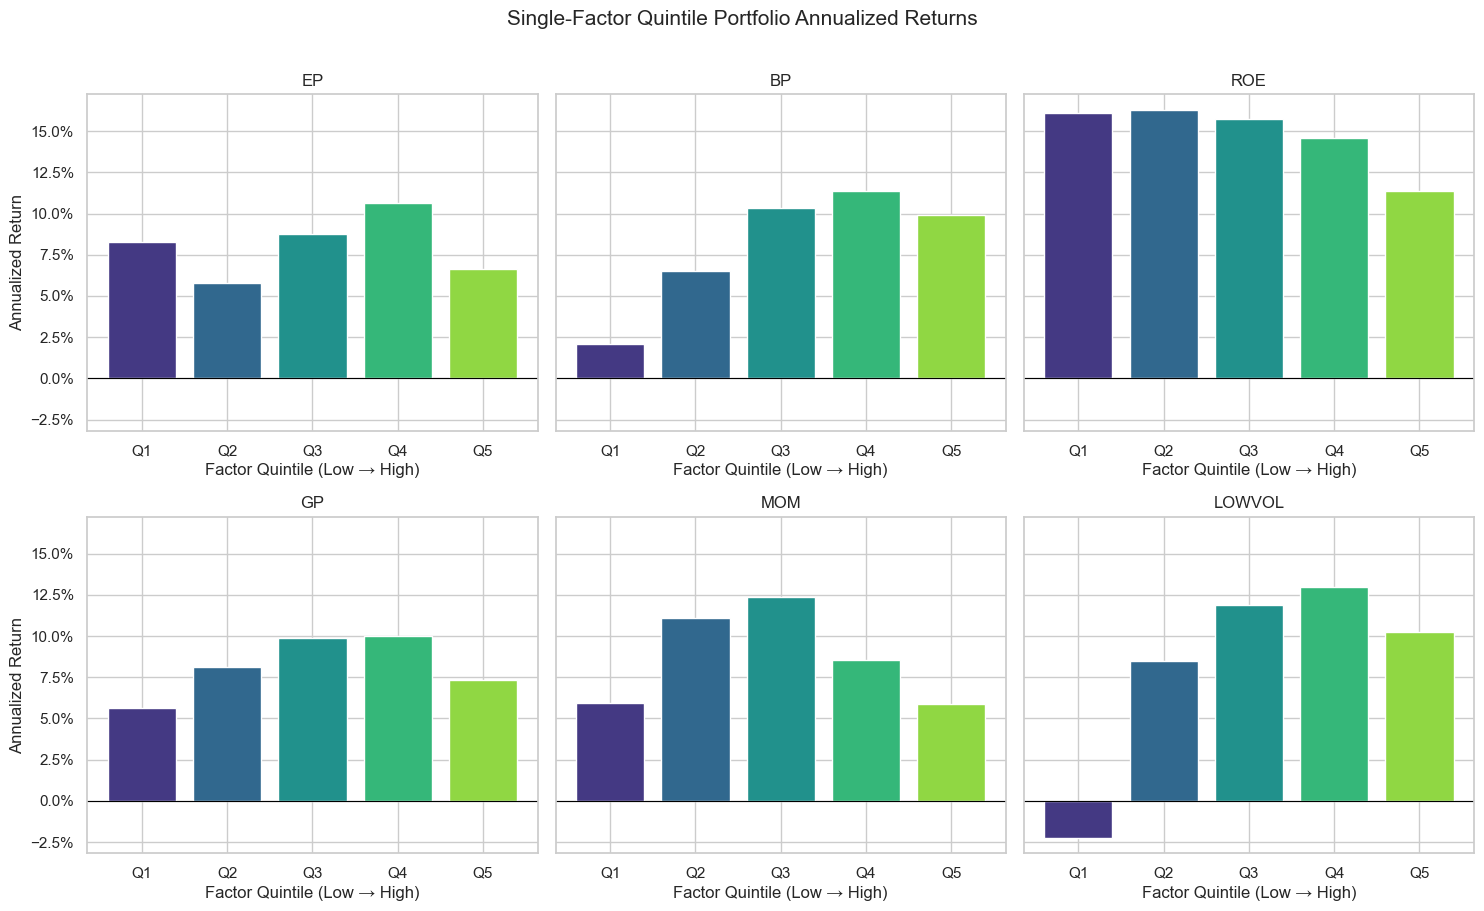

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
colors = sns.color_palette('viridis', N_QUINTILES)
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    values = annualized_quintile_returns.loc[factor, QUINTILES]
    ax.bar(QUINTILES, values, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(FACTOR_LABELS[factor])
    ax.set_xlabel('Factor Quintile (Low → High)')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 0].set_ylabel('Annualized Return')
axes[1, 0].set_ylabel('Annualized Return')
fig.suptitle('Single-Factor Quintile Portfolio Annualized Returns', y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'single_factor_quintile_annualized_returns.png',
    dpi=160,
    bbox_inches='tight',
)
plt.show()

## 5. Q5−Q1 多空组合核心指标

年化收益由多空月收益自身复利计算，并不等于上表中 Q5 年化收益减 Q1 年化收益。最大回撤从初始净值 1 开始计算，胜率是多空月收益大于零的月份比例。

In [6]:
long_short_metrics = pd.DataFrame({
    factor: calculate_return_metrics(
        panel['Long-Short'], periods_per_year=PERIODS_PER_YEAR
    )
    for factor, panel in factor_return_panels.items()
}).T.rename(index=FACTOR_LABELS)
long_short_metrics['Months'] = long_short_metrics['Months'].astype('int64')
display(
    long_short_metrics.style
    .format({
        'Annualized Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe Ratio': '{:.2f}',
        'Maximum Drawdown': '{:.2%}',
        'Win Rate': '{:.1%}',
        'Months': '{:.0f}',
    })
    .background_gradient(subset=['Annualized Return', 'Sharpe Ratio'], cmap='RdYlGn')
)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Win Rate,Months
EP,-4.14%,14.17%,-0.23,-36.39%,52.6%,95
BP,5.14%,16.58%,0.38,-29.92%,49.5%,95
ROE,-6.31%,14.50%,-0.38,-53.98%,40.7%,86
GP,0.52%,12.03%,0.10,-33.26%,54.7%,95
MOM,-1.63%,15.26%,-0.03,-35.40%,50.5%,95
LOWVOL,8.68%,18.14%,0.55,-17.21%,56.8%,95


## 6. Q1、Q5与Q5−Q1累计收益曲线

累计收益以月度简单收益复利计算。横轴是信号形成日，对应的收益在其后的一个持有期内实现。多空曲线是研究型合成净值，没有加入融券约束、借券成本或其他交易成本。

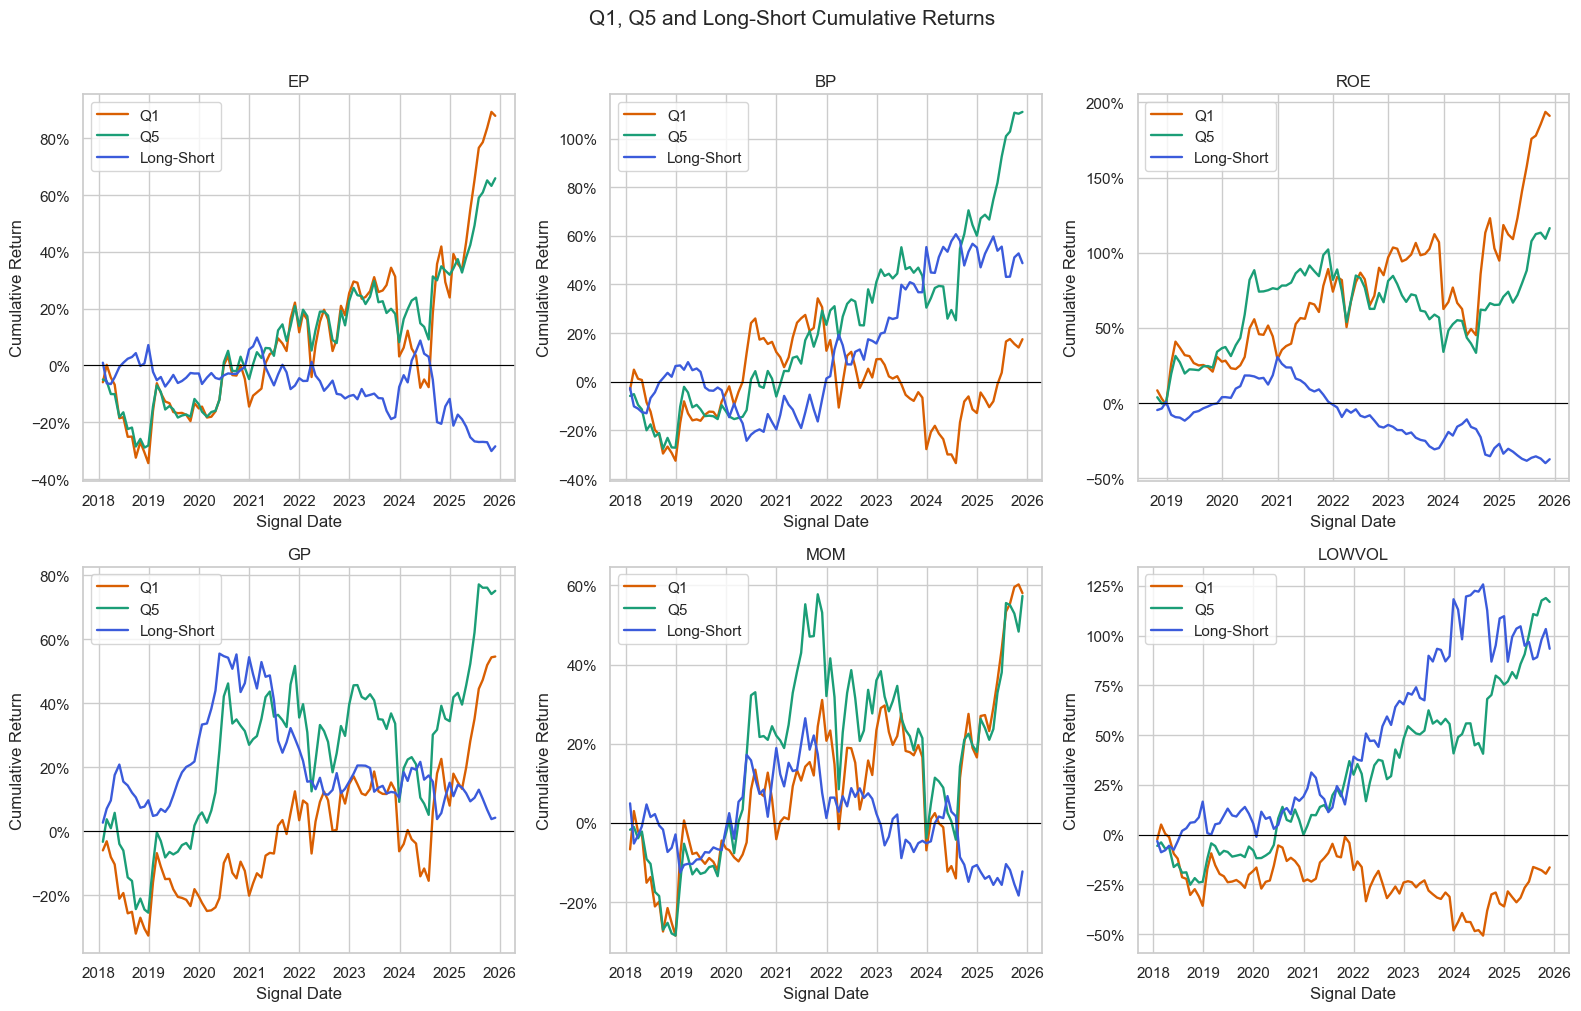

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
line_colors = {'Q1': '#d95f02', 'Q5': '#1b9e77', 'Long-Short': '#3b5bdb'}
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    panel = factor_return_panels[factor]
    for portfolio in ['Q1', 'Q5', 'Long-Short']:
        curve = calculate_cumulative_returns(panel[portfolio])
        ax.plot(
            curve.index, curve, label=portfolio,
            color=line_colors[portfolio], linewidth=1.7,
        )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(FACTOR_LABELS[factor])
    ax.set_xlabel('Signal Date')
    ax.set_ylabel('Cumulative Return')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc='upper left')
fig.suptitle('Q1, Q5 and Long-Short Cumulative Returns', y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / 'single_factor_cumulative_returns.png',
    dpi=160,
    bbox_inches='tight',
)
plt.show()

## 7. 核心结论

In [8]:
best_return_factor = long_short_metrics['Annualized Return'].idxmax()
best_sharpe_factor = long_short_metrics['Sharpe Ratio'].idxmax()
best_monotonic_factor = quintile_summary['Monotonicity'].idxmax()
print(
    f"多空年化收益最高：{best_return_factor} "
    f"({long_short_metrics.loc[best_return_factor, 'Annualized Return']:.2%})"
)
print(
    f"多空 Sharpe 最高：{best_sharpe_factor} "
    f"({long_short_metrics.loc[best_sharpe_factor, 'Sharpe Ratio']:.2f})"
)
print(
    f"分组单调性最高：{best_monotonic_factor} "
    f"({quintile_summary.loc[best_monotonic_factor, 'Monotonicity']:.2f})"
)
print('这些结果尚未中性化，也未扣除换手和交易成本；不能直接视为可实现业绩。')

多空年化收益最高：LOWVOL (8.68%)
多空 Sharpe 最高：LOWVOL (0.55)
分组单调性最高：BP (0.70)
这些结果尚未中性化，也未扣除换手和交易成本；不能直接视为可实现业绩。


## 图形输出

本 Notebook 只保存 README 要求的两类图形，不保存额外中间表格：

- `figures/single_factor_quintile_annualized_returns.png`
- `figures/single_factor_cumulative_returns.png`